**Table of contents**<a id='toc0_'></a>    
- [Photoswitching fingerprints of 1 fluorophore - additional data](#toc1_)    
  - [CDF Fitting procedure](#toc1_1_)    
  - [Reading and fitting data](#toc1_2_)    
    - [Bleaching rate data](#toc1_2_1_)    
    - [ON to OFF data](#toc1_2_2_)    
    - [OFF to ON data](#toc1_2_3_)    
    - [ON to OFF no bleaching](#toc1_2_4_)    
    - [OFF to ON no bleaching](#toc1_2_5_)    
  - [Figure](#toc1_3_)    
    - [Preparation](#toc1_3_1_)    
    - [Figure](#toc1_3_2_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[Photoswitching fingerprints of 1 fluorophore - additional data](#toc0_)

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from brokenaxes import brokenaxes
from lmfit import Model, Parameters
from matplotlib import rcParams

import fluopy.blinking as bl
import fluopy.distributions as dist
import fluopy.emissions as em
import fluopy.figure as fi
import fluopy.miscellaneous as mi

%load_ext autoreload
%autoreload 2

reading_from_1 = (
    r"C:\Users\vie43sq\data_vincent\python_output\Chapter_I\0_3_single_f_PFA"
)
reading_from_2 = (
    r"C:\Users\vie43sq\data_vincent\python_output\Chapter_I\1_5_single_f_PFA_add"
)

## <a id='toc1_1_'></a>[CDF Fitting procedure](#toc0_)

In [2]:
def target_cdf(x, p, lambda1, lambda2):
    mixture = dist.ExponentialMixtureModel(
        params={"pis": [p], "lambdas": [lambda1, lambda2]}, domain=(0, 300)
    )
    return mixture.cdf(x)


def fit_two_expon_mixture(data):
    x = np.linspace(0, 300, 300001)
    model = Model(target_cdf)
    params = Parameters()
    params.add("p", value=0.5, min=0, max=1)
    params.add("lambda1", value=1, min=0)
    params.add("lambda2", value=0.5, min=0)
    result = model.fit(data, params, x=x)
    parameters = [param.value for param in result.params.values()]

    return parameters

## <a id='toc1_2_'></a>[Reading and fitting data](#toc0_)

### <a id='toc1_2_1_'></a>[Bleaching rate data](#toc0_)

In [3]:
identifiers = ["1e1", "1e2", "1e3", "1e4"]
fingerprints_all_A = []
total_photons_A = []
ON_periods_A_frames = []
OFF_periods_A_frames = []
parameters_all_fit_cdf_A = []
folder_path = reading_from_1 + r"\bl_rate"
emis = em.Emissions()
for i, id in enumerate(identifiers):
    fingerprints_all_A.append(
        pd.Series(
            np.zeros(300001),
            np.round(np.linspace(0, 300, 300001), decimals=12),
            dtype=np.int32,
        )
    )
    total_photons_A.append([])
    ON_periods_A_frames.append([])
    OFF_periods_A_frames.append([])
    for file in Path(folder_path + "\\" + id).iterdir():
        if file.suffix == ".parquet":
            data = pd.read_parquet(file)
            fingerprints_all_A[i] += data.sum(axis=1)
            total_photons_A[i] += data.sum(axis=0).values.tolist()
            for col in data.columns:
                emis.event_time_series = data[col]
                blinks = bl.Blinking(emis)
                OFF_periods_A_frames[i] += blinks.off_periods.tolist()
                ON_periods_A_frames[i] += blinks.on_periods.tolist()
    fingerprint = fingerprints_all_A[i].cumsum() / fingerprints_all_A[i].sum()
    fingerprints_all_A[i] = fingerprint
    parameters_all_fit_cdf_A.append(fit_two_expon_mixture(fingerprint))

### <a id='toc1_2_2_'></a>[ON to OFF data](#toc0_)

In [4]:
identifiers = ["1", "01", "005", "001"]
fingerprints_all_B = []
total_photons_B = []
ON_periods_B_frames = []
OFF_periods_B_frames = []
parameters_all_fit_cdf_B = []
folder_path = reading_from_1 + r"\off_prob"
emis = em.Emissions()
for i, id in enumerate(identifiers):
    fingerprints_all_B.append(
        pd.Series(
            np.zeros(300001),
            np.round(np.linspace(0, 300, 300001), decimals=12),
            dtype=np.int32,
        )
    )
    total_photons_B.append([])
    ON_periods_B_frames.append([])
    OFF_periods_B_frames.append([])
    for file in Path(folder_path + "\\" + id).iterdir():
        if file.suffix == ".parquet":
            data = pd.read_parquet(file)
            fingerprints_all_B[i] += data.sum(axis=1)
            total_photons_B[i] += data.sum(axis=0).values.tolist()
            for col in data.columns:
                emis.event_time_series = data[col]
                blinks = bl.Blinking(emis)
                ON_periods_B_frames[i] += blinks.on_periods.tolist()
                OFF_periods_B_frames[i] += blinks.off_periods.tolist()
    fingerprint = fingerprints_all_B[i].cumsum() / fingerprints_all_B[i].sum()
    fingerprints_all_B[i] = fingerprint
    parameters_all_fit_cdf_B.append(fit_two_expon_mixture(fingerprint))

### <a id='toc1_2_3_'></a>[OFF to ON data](#toc0_)

In [5]:
identifiers = ["5e-2", "5e-1", "5e0", "5e1"]
fingerprints_all_C = []
total_photons_C = []
ON_periods_C_frames = []
OFF_periods_C_frames = []
parameters_all_fit_cdf_C = []
folder_path = reading_from_1 + r"\off_time"
emis = em.Emissions()
for i, id in enumerate(identifiers):
    fingerprints_all_C.append(
        pd.Series(
            np.zeros(300001),
            np.round(np.linspace(0, 300, 300001), decimals=12),
            dtype=np.int32,
        )
    )
    total_photons_C.append([])
    ON_periods_C_frames.append([])
    OFF_periods_C_frames.append([])
    for file in Path(folder_path + "\\" + id).iterdir():
        if file.suffix == ".parquet":
            data = pd.read_parquet(file)
            fingerprints_all_C[i] += data.sum(axis=1)
            total_photons_C[i] += data.sum(axis=0).values.tolist()
            for col in data.columns:
                emis.event_time_series = data[col]
                blinks = bl.Blinking(emis)
                ON_periods_C_frames[i] += blinks.on_periods.tolist()
                OFF_periods_C_frames[i] += blinks.off_periods.tolist()
    fingerprint = fingerprints_all_C[i].cumsum() / fingerprints_all_C[i].sum()
    fingerprints_all_C[i] = fingerprint
    parameters_all_fit_cdf_C.append(fit_two_expon_mixture(fingerprint))

### <a id='toc1_2_4_'></a>[ON to OFF no bleaching](#toc0_)

In [6]:
identifiers = ["1", "01", "005", "001"]
fingerprints_all_D = []
parameters_all_fit_cdf_D = []
folder_path = reading_from_2 + r"\off_prob_no_bl"
for i, id in enumerate(identifiers):
    fingerprints_all_D.append(
        pd.Series(
            np.zeros(300001),
            np.round(np.linspace(0, 300, 300001), decimals=12),
            dtype=np.int32,
        )
    )
    for file in Path(folder_path + "\\" + id).iterdir():
        if file.suffix == ".parquet":
            data = pd.read_parquet(file)
            fingerprints_all_D[i] += data.sum(axis=1)
    fingerprint = fingerprints_all_D[i].cumsum() / fingerprints_all_D[i].sum()
    fingerprints_all_D[i] = fingerprint
    parameters_all_fit_cdf_D.append(fit_two_expon_mixture(fingerprint))

### <a id='toc1_2_5_'></a>[OFF to ON no bleaching](#toc0_)

In [7]:
identifiers = ["5e-2", "5e-1", "5e0", "5e1"]
fingerprints_all_E = []
parameters_all_fit_cdf_E = []
folder_path = reading_from_2 + r"\off_time_no_bl"
for i, id in enumerate(identifiers):
    fingerprints_all_E.append(
        pd.Series(
            np.zeros(300001),
            np.round(np.linspace(0, 300, 300001), decimals=12),
            dtype=np.int32,
        )
    )
    for file in Path(folder_path + "\\" + id).iterdir():
        if file.suffix == ".parquet":
            data = pd.read_parquet(file)
            fingerprints_all_E[i] += data.sum(axis=1)
    fingerprint = fingerprints_all_E[i].cumsum() / fingerprints_all_E[i].sum()
    fingerprints_all_E[i] = fingerprint
    parameters_all_fit_cdf_E.append(fit_two_expon_mixture(fingerprint))

## <a id='toc1_3_'></a>[Figure](#toc0_)

### <a id='toc1_3_1_'></a>[Preparation](#toc0_)

In [8]:
def get_log_bins(data):
    minimum = np.min([np.min(a) for a in data])
    if minimum == 0:
        minimum = 1
    maximum = np.max([np.max(a) for a in data])
    log_bins = np.logspace(np.log10(minimum), np.log10(maximum), 50)
    return log_bins


def prepare_data(total_photons, ON_periods_frames, OFF_periods_frames, in_s):
    total_photons = [np.array(d) for d in total_photons]
    ON_periods = [np.array(d) * in_s for d in ON_periods_frames]
    OFF_periods = [np.array(d) * in_s for d in OFF_periods_frames]
    log_bins_photons = get_log_bins(total_photons)
    log_bins_OFF = get_log_bins(OFF_periods)
    weights_photons = [np.ones_like(d) / d.size for d in total_photons]
    weights_ON = [np.ones_like(d) / d.size for d in ON_periods]
    weights_OFF = [np.ones_like(d) / d.size for d in OFF_periods]
    return (
        total_photons,
        ON_periods,
        OFF_periods,
        log_bins_photons,
        log_bins_OFF,
        weights_photons,
        weights_ON,
        weights_OFF,
    )


in_s = emis.event_time_series.index[1] - emis.event_time_series.index[0]
(
    total_photons_A,
    ON_periods_A,
    OFF_periods_A,
    log_bins_photons_A,
    log_bins_OFF_A,
    weights_photons_A,
    weights_ON_A,
    weights_OFF_A,
) = prepare_data(total_photons_A, ON_periods_A_frames, OFF_periods_A_frames, in_s)
(
    total_photons_B,
    ON_periods_B,
    OFF_periods_B,
    log_bins_photons_B,
    log_bins_OFF_B,
    weights_photons_B,
    weights_ON_B,
    weights_OFF_B,
) = prepare_data(total_photons_B, ON_periods_B_frames, OFF_periods_B_frames, in_s)
(
    total_photons_C,
    ON_periods_C,
    OFF_periods_C,
    log_bins_photons_C,
    log_bins_OFF_C,
    weights_photons_C,
    weights_ON_C,
    weights_OFF_C,
) = prepare_data(total_photons_C, ON_periods_C_frames, OFF_periods_C_frames, in_s)

### <a id='toc1_3_2_'></a>[Figure](#toc0_)

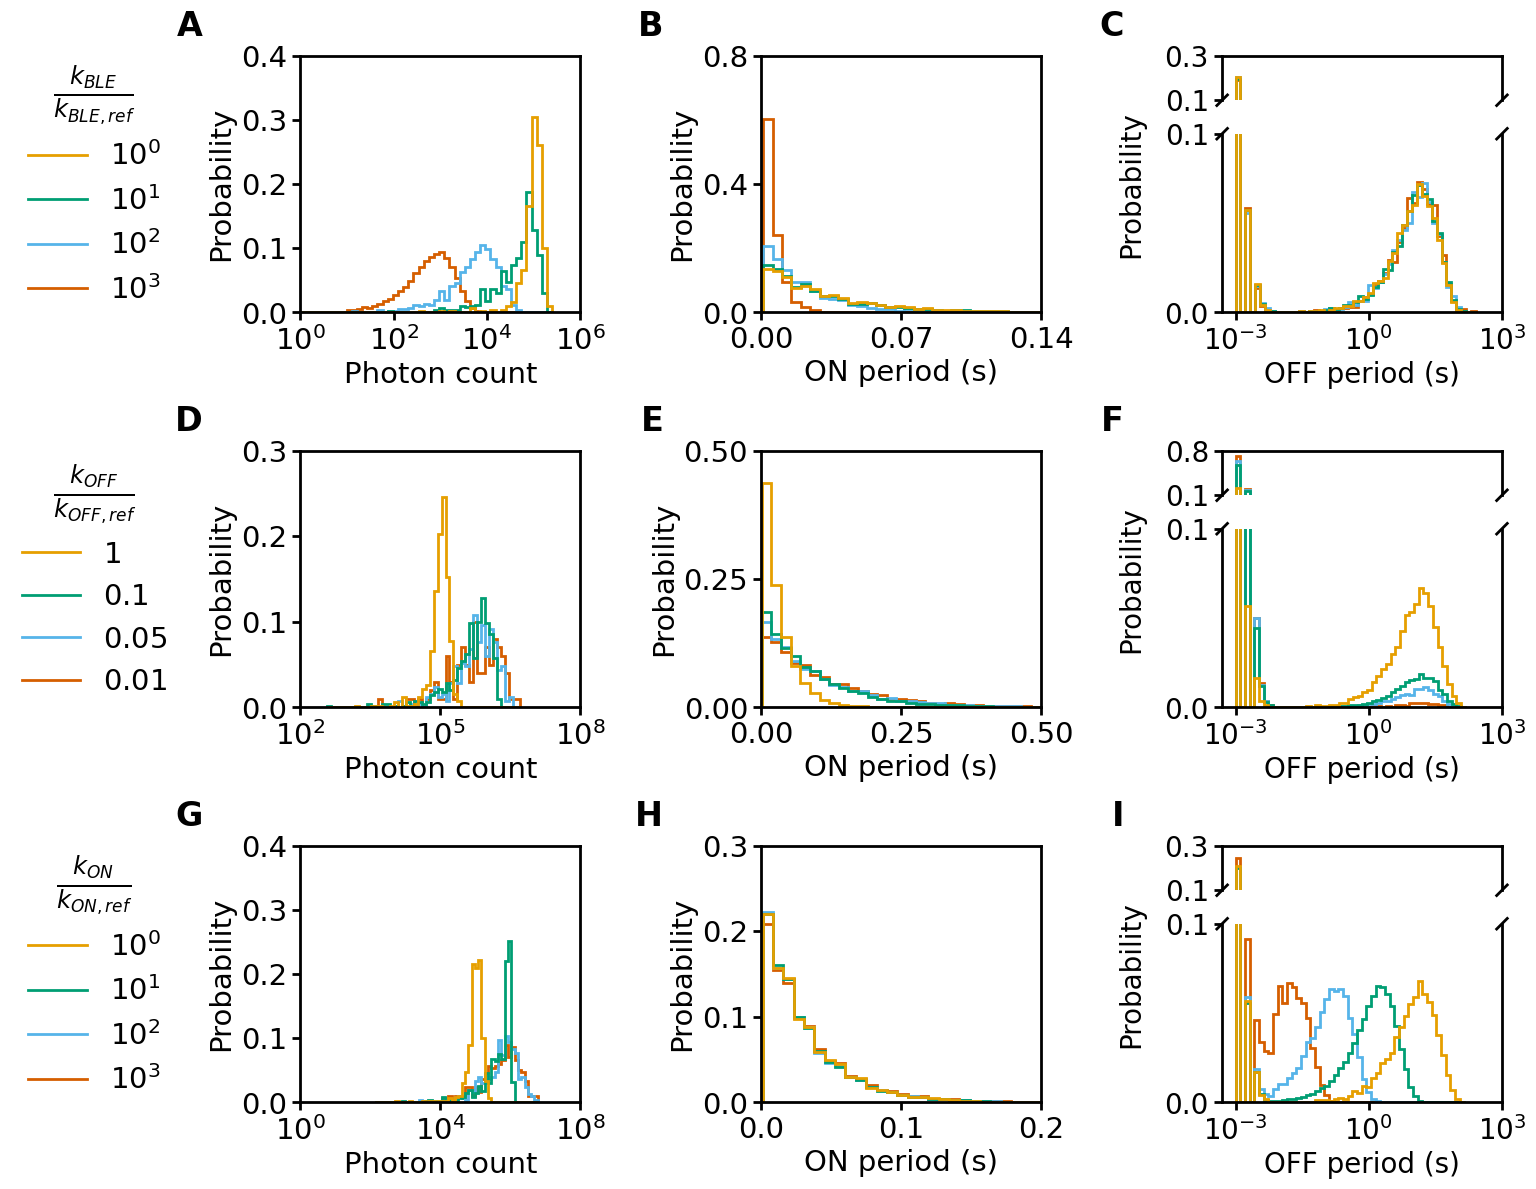

In [9]:
from matplotlib.lines import Line2D

red = "#D55E00"
sky_blue = "#56B4E9"
green = "#009E73"
orange = "#E69F00"
colors = [orange, green, sky_blue, red]

custom_handles = [
    Line2D([0], [0], color=orange, lw=2),
    Line2D([0], [0], color=green, lw=2),
    Line2D([0], [0], color=sky_blue, lw=2),
    Line2D([0], [0], color=red, lw=2),
]

rcParams["axes.linewidth"] = 2
gs = plt.GridSpec(3, 7)
fig = plt.figure(figsize=(15, 12))
ax123 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1:3])
labels1 = [r"$10^{0}$", r"$10^{1}$", r"$10^{2}$", r"$10^{3}$"]
legendtitle1 = r"$\frac{k_{BLE}}{k_{BLE,ref}}$"
fi.universal_figure(
    type_="hist",
    data=total_photons_A,
    axes=ax1,
    density=False,
    histtype="step",
    lw=2,
    label=labels1,
    color=colors,
    alpha=1,
    weights=weights_photons_A,
    xscale="log",
    bins=log_bins_photons_A,
    ylim=[0, 0.4],
    xlim=[1e0, 1e6],
    ylabel="Probability",
    xlabel="Photon count",
)

ax2 = fig.add_subplot(gs[0, 3:5])
fi.universal_figure(
    type_="hist",
    data=ON_periods_A,
    axes=ax2,
    density=False,
    label=labels1,
    color=colors,
    alpha=1,
    weights=weights_ON_A,
    ylabel="Probability",
    xlabel="ON period (s)",
    histtype="step",
    lw=2,
    bins=60,
    ylim=[0, 0.8],
    xlim=[0, 0.14],
    xticks=[0, 0.07, 0.14],
    yticks=[0, 0.4, 0.8],
)

bax3 = brokenaxes(
    ylims=((0, 0.1), (0.1, 0.3)),
    subplot_spec=gs[0, 5:7],
    despine=False,
    d=0.005,
    height_ratios=(1, 4),
    hspace=0.3,
)
bax3.hist(
    OFF_periods_A,
    density=False,
    histtype="step",
    lw=2,
    label=labels1,
    color=colors,
    alpha=1,
    bins=log_bins_OFF_A,
    weights=weights_OFF_A,
)
bax3.set_xscale("log")
bax3.set_ylabel("Probability", fontsize=20, labelpad=55)
bax3.set_xlabel("OFF period (s)", fontsize=20, labelpad=35)
bax3.tick_params(labelsize=20, width=2, length=6)
bax3.set_xlim([5e-4, 1e3])
bax3.set_xticks([1e-3, 1e0, 1e3])
bax3.axs[0].set_yticks([0.1, 0.3])
bax3.axs[1].set_yticks([0, 0.1])

ax123.axis("off")
ax123.legend(
    custom_handles,
    labels1,
    loc="center",
    frameon=False,
    fontsize=21,
    title=legendtitle1,
    title_fontsize=25,
)

ax456 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1:3])
labels3 = [r"$1$", r"$0.1$", r"$0.05$", r"$0.01$"]
legendtitle3 = r"$\frac{k_{OFF}}{k_{OFF,ref}}$"
fi.universal_figure(
    type_="hist",
    data=total_photons_B,
    axes=ax4,
    density=False,
    histtype="step",
    lw=2,
    label=labels3,
    color=colors,
    alpha=1,
    weights=weights_photons_B,
    xscale="log",
    bins=log_bins_photons_B,
    ylim=[0, 0.3],
    xlim=[1e2, 1e8],
    ylabel="Probability",
    xlabel="Photon count",
)

ax5 = fig.add_subplot(gs[1, 3:5])
fi.universal_figure(
    type_="hist",
    data=ON_periods_B,
    axes=ax5,
    density=False,
    label=labels3,
    color=colors,
    alpha=1,
    weights=weights_ON_B,
    ylabel="Probability",
    xlabel="ON period (s)",
    histtype="step",
    lw=2,
    bins=60,
    ylim=[0, 0.5],
    xlim=[0, 0.5],
    xticks=[0, 0.25, 0.5],
    yticks=[0, 0.25, 0.5],
)

bax6 = brokenaxes(
    ylims=((0, 0.1), (0.1, 0.8)),
    subplot_spec=gs[1, 5:7],
    despine=False,
    d=0.005,
    height_ratios=(1, 4),
    hspace=0.3,
)
bax6.hist(
    OFF_periods_B,
    density=False,
    histtype="step",
    lw=2,
    label=labels3,
    color=colors,
    alpha=1,
    bins=log_bins_OFF_B,
    weights=weights_OFF_B,
)
bax6.set_xscale("log")
bax6.set_ylabel("Probability", fontsize=20, labelpad=55)
bax6.set_xlabel("OFF period (s)", fontsize=20, labelpad=35)
bax6.tick_params(labelsize=20, width=2, length=6)
bax6.set_xlim([5e-4, 1e3])
bax6.set_xticks([1e-3, 1e0, 1e3])
bax6.axs[0].set_yticks([0.1, 0.8])
bax6.axs[1].set_yticks([0, 0.1])

ax456.axis("off")
ax456.legend(
    custom_handles,
    labels3,
    loc="center",
    frameon=False,
    fontsize=21,
    title=legendtitle3,
    title_fontsize=25,
)

ax789 = fig.add_subplot(gs[2, 0])
ax7 = fig.add_subplot(gs[2, 1:3])
labels5 = [r"$10^{0}$", r"$10^{1}$", r"$10^{2}$", r"$10^{3}$"]
legendtitle5 = r"$\frac{k_{ON}}{k_{ON,ref}}$"
fi.universal_figure(
    type_="hist",
    data=total_photons_C,
    axes=ax7,
    density=False,
    histtype="step",
    lw=2,
    label=labels5,
    color=colors,
    alpha=1,
    weights=weights_photons_C,
    xscale="log",
    bins=log_bins_photons_C,
    ylim=[0, 0.4],
    xlim=[1e0, 1e8],
    xticks=[1e0, 1e4, 1e8],
    ylabel="Probability",
    xlabel="Photon count",
)

ax8 = fig.add_subplot(gs[2, 3:5])
fi.universal_figure(
    type_="hist",
    data=ON_periods_C,
    axes=ax8,
    density=False,
    label=labels5,
    color=colors,
    alpha=1,
    weights=weights_ON_C,
    ylabel="Probability",
    xlabel="ON period (s)",
    histtype="step",
    lw=2,
    bins=60,
    ylim=[0, 0.3],
    xlim=[0, 0.2],
)

bax9 = brokenaxes(
    ylims=((0, 0.1), (0.1, 0.3)),
    subplot_spec=gs[2, 5:7],
    despine=False,
    d=0.005,
    height_ratios=(1, 4),
    hspace=0.3,
)
bax9.hist(
    OFF_periods_C,
    density=False,
    histtype="step",
    lw=2,
    label=labels5,
    color=colors,
    alpha=1,
    bins=log_bins_OFF_C,
    weights=weights_OFF_C,
)
bax9.set_xscale("log")
bax9.set_ylabel("Probability", fontsize=20, labelpad=55)
bax9.set_xlabel("OFF period (s)", fontsize=20, labelpad=35)
bax9.tick_params(labelsize=20, width=2, length=6)
bax9.set_xlim([5e-4, 1e3])
bax9.set_xticks([1e-3, 1e0, 1e3])
bax9.axs[0].set_yticks([0.1, 0.3])
bax9.axs[1].set_yticks([0, 0.1])

ax789.axis("off")
ax789.legend(
    custom_handles,
    labels5,
    loc="center",
    frameon=False,
    fontsize=21,
    title=legendtitle5,
    title_fontsize=25,
)


axes = fig.get_axes()
letters = ["A", "B", "C", "D", "E", "F", "G", "H", "I"]
j = 0
for i, axis in enumerate(axes):
    if i in [0, 3, 4, 6, 9, 10, 12, 15, 16]:
        continue
    offset = -0.35
    axis.text(
        -0.35,
        1.05,
        letters[j],
        transform=axis.transAxes,
        fontsize=24,
        fontweight="bold",
        va="bottom",
        ha="right",
    )
    j += 1
fig.tight_layout()
for handle3, handle6, handle9 in zip(
    bax3.diag_handles, bax6.diag_handles, bax9.diag_handles
):
    handle3.remove()
    handle6.remove()
    handle9.remove()
bax3.draw_diags()
bax6.draw_diags()
bax9.draw_diags()
bbox = mi.compute_tight_bbox(fig, pad_inches=0.1)
fig.savefig(
    reading_from_2 + r"\single_f_PFA_add.png",
    dpi=300,
    bbox_inches=bbox,
)

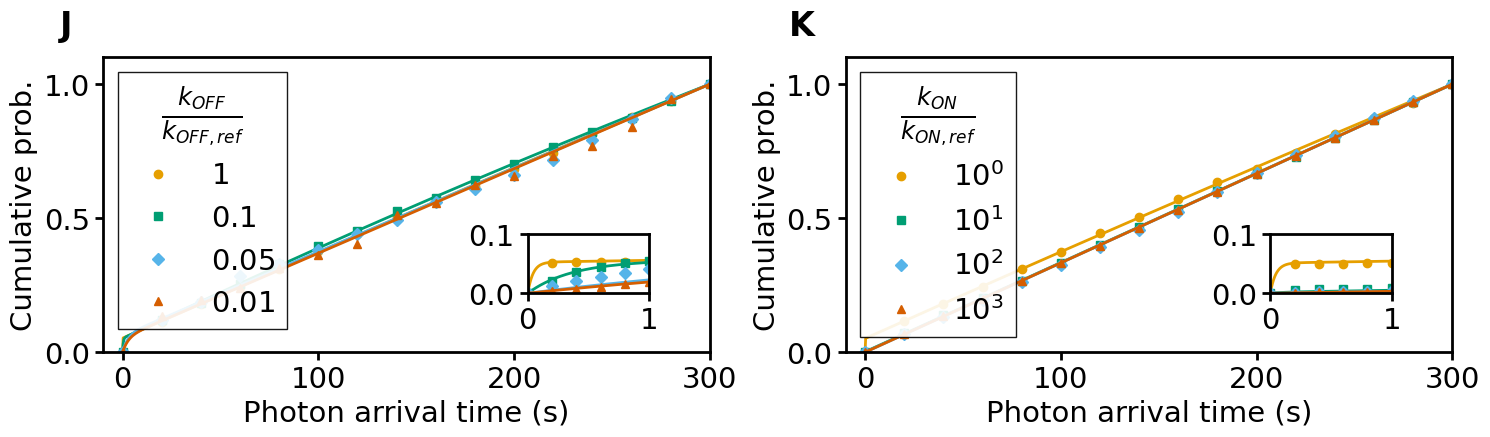

In [10]:
def plot_figure3(
    ax, labels, data, fit, legendtitle, xlim2, ylim2, spacing2, colors=colors
):
    markers = ["o", "s", "D", "^"]
    x = np.linspace(0, 300, 1000)
    spacing1 = 20000
    description = dict(
        ylabel="Cumulative prob.",
        xlabel="Photon arrival time (s)",
        legend=True,
        xlim=[-10, 300],
        ylim=[0, 1.1],
        yticks=[0, 0.5, 1],
    )
    for fingerprint, parameters, label, color, marker in zip(
        data, fit, labels, colors, markers
    ):
        pi, lambda1, lambda2 = parameters
        fi.universal_figure(
            data=[fingerprint.index[::spacing1], fingerprint[::spacing1]],
            label=label,
            color=color,
            marker=marker,
            linestyle="",
            axes=ax,
        )
        fi.universal_figure(
            data=[
                x,
                dist.ExponentialMixtureModel(
                    params={"pis": [pi], "lambdas": [lambda1, lambda2]}, domain=(0, 300)
                ).cdf(x),
            ],
            color=color,
            axes=ax,
            lw=2,
        )
    fi.universal_figure(
        axes=ax,
        legendargs=dict(
            title=legendtitle,
            framealpha=1,
            edgecolor="black",
            fancybox=False,
            title_fontsize=25,
            fontsize=21,
        ),
        **description,
    )
    ax.get_legend().get_frame().set_alpha(0.9)

    inset = ax.inset_axes([0.7, 0.2, 0.2, 0.2], xlim=(0, xlim2), ylim=(0, ylim2))
    x = np.linspace(0, 300, 100000)
    for fingerprint, parameters, label, color, marker in zip(
        data, fit, labels, colors, markers
    ):
        pi, lambda1, lambda2 = parameters
        fi.universal_figure(
            data=[fingerprint.index[::spacing2], fingerprint[::spacing2]],
            axes=inset,
            label=label,
            color=color,
            marker=marker,
            linestyle="",
        )
        fi.universal_figure(
            data=[
                x,
                dist.ExponentialMixtureModel(
                    params={"pis": [pi], "lambdas": [lambda1, lambda2]}, domain=(0, 300)
                ).cdf(x),
            ],
            axes=inset,
            color=color,
            lw=2,
        )
    inset.set_ylabel("")
    inset.set_xlabel("")


gs = plt.GridSpec(1, 2)
fig = plt.figure(figsize=(15, 4.5))
ax10 = fig.add_subplot(gs[0, 0])
labels10 = [r"$1$", r"$0.1$", r"$0.05$", r"$0.01$"]
legendtitle10 = r"$\frac{k_{OFF}}{k_{OFF,ref}}$"
plot_figure3(
    ax10,
    labels10,
    fingerprints_all_D,
    parameters_all_fit_cdf_D,
    legendtitle10,
    1,
    0.1,
    200,
)

ax11 = fig.add_subplot(gs[0, 1])
labels11 = [r"$10^{0}$", r"$10^{1}$", r"$10^{2}$", r"$10^{3}$"]
legendtitle11 = r"$\frac{k_{ON}}{k_{ON,ref}}$"
plot_figure3(
    ax11,
    labels11,
    fingerprints_all_E,
    parameters_all_fit_cdf_E,
    legendtitle11,
    1,
    0.1,
    200,
)

axes = fig.get_axes()
letters = ["J", "K"]
for i, axis in enumerate(axes):
    axis.text(
        -0.05,
        1.05,
        letters[i],
        transform=axis.transAxes,
        fontsize=24,
        fontweight="bold",
        va="bottom",
        ha="right",
    )

fig.tight_layout()
bbox = mi.compute_tight_bbox(fig, pad_inches=0.1)
fig.savefig(
    reading_from_2 + r"\single_f_PFA_add_2.png",
    dpi=300,
    bbox_inches=bbox,
)

#### Merging the two figures into one

In [ ]:
from PIL import Image

fig1 = Image.open(reading_from_2 + r"\single_f_PFA_add.png")
fig2 = Image.open(reading_from_2 + r"\single_f_PFA_add_2.png")

combined_height = fig1.height + fig2.height
width = fig1.width

combined = Image.new("RGB", (width, combined_height), (255, 255, 255))
combined.paste(fig1, (0, 0))
combined.paste(fig2, (0, fig1.height))

combined.save(reading_from_2 + r"\merged.png", dpi=(300, 300))

: 